<a href="https://colab.research.google.com/github/justine-AI12/customer-segmentation-ml/blob/main/Segmentation_Client_Mall_Customers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Segmentation Client Premium - Mall Customer Analytics
## Identifier des segments clients actionnables pour personnaliser les campagnes marketing et optimiser le ROI

**Objectif:** construire un projet de segmentation client complet.

**Dataset :** Mall Customer Segmentation Dataset  
**Variables :** `CustomerID`, `Gender`, `Age`, `Annual Income (k$)`, `Spending Score (1-100)`

## 1. Executive Summary

Ce projet répond à une problématique classique de **Customer Analytics** : transformer une base client brute en segments homogènes, compréhensibles et activables par les équipes marketing.

La démarche suit une logique de consultant analytics :

- **Comprendre la donnée** : qualité, distributions, relations entre âge, revenu et score de dépense.
- **Préparer les variables** : nettoyage, encodage, standardisation et sélection de variables pertinentes.
- **Comparer plusieurs algorithmes** : K-Means, clustering hiérarchique et DBSCAN.
- **Choisir un modèle final** : combinaison d'indicateurs quantitatifs et de lisibilité métier.
- **Traduire les clusters en personas marketing** : nom commercial, profil, poids, potentiel et recommandations.

> **Message clé :** le meilleur modèle n'est pas seulement celui qui maximise une métrique. Pour un usage marketing, il doit aussi produire des groupes stables, interprétables et directement actionnables.

## 2. Contexte Métier & Objectifs

Une entreprise de centre commercial souhaite mieux comprendre ses clients afin de personnaliser ses campagnes, prioriser ses investissements marketing et améliorer son retour sur investissement.

### Questions business

1. Existe-t-il des groupes naturels de clients selon leur âge, revenu annuel et score de dépense ?
2. Quels segments présentent le plus fort potentiel commercial ?
3. Quels segments nécessitent une stratégie de fidélisation, d'upsell ou de réactivation ?
4. Comment transformer un résultat de clustering en recommandations utilisables par une équipe marketing ?

### Livrables analytiques attendus

- Analyse exploratoire claire et visuelle.
- Pipeline de préparation reproductible.
- Comparaison K-Means, CAH et DBSCAN.
- Visualisations 2D et 3D interactives.
- Tableau final des segments et recommandations stratégiques.

## 3. Setup & Chargement des Données

In [3]:
# Core data stack
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Machine learning
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors

# Hierarchical clustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Display
from IPython.display import display, HTML

RANDOM_STATE = 42
DATA_PATH = Path("Mall_Customers.csv")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titleweight"] = "bold"

PALETTE = ["#2F80ED", "#27AE60", "#F2994A", "#EB5757", "#9B51E0", "#00A6A6", "#F2C94C", "#4F4F4F"]
px.defaults.template = "plotly_white"
px.defaults.color_discrete_sequence = PALETTE

In [4]:
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

print(f"Nombre de lignes : {df.shape[0]:,}")
print(f"Nombre de colonnes : {df.shape[1]:,}")
display(df.head())

Nombre de lignes : 200
Nombre de colonnes : 5


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 4. Analyse Exploratoire des Données (EDA)

L'EDA vise ? comprendre les variables disponibles, détecter d'éventuels problèmes de qualité et identifier les premiers patterns utiles pour le clustering.

In [5]:
summary = pd.DataFrame({
    "type": df.dtypes.astype(str),
    "missing_values": df.isna().sum(),
    "missing_rate_%": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique()
})

display(summary)
display(df.describe(include="all").T)

,type,missing_values,missing_rate_%,unique_values
CustomerID,int64,0,0.0,200
Gender,object,0,0.0,2
Age,int64,0,0.0,51
Annual Income (k$),int64,0,0.0,64
Spending Score (1-100),int64,0,0.0,84


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,200.0,NaN,NaN,NaN,100.5,57.879185,1.0,50.75,100.5,150.25,200.0
Gender,200,2,Female,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,200.0,NaN,NaN,NaN,38.85,13.969007,18.0,28.75,36.0,49.0,70.0
Annual Income (k$),200.0,NaN,NaN,NaN,60.56,26.264721,15.0,41.5,61.5,78.0,137.0
Spending Score (1-100),200.0,NaN,NaN,NaN,50.2,25.823522,1.0,34.75,50.0,73.0,99.0


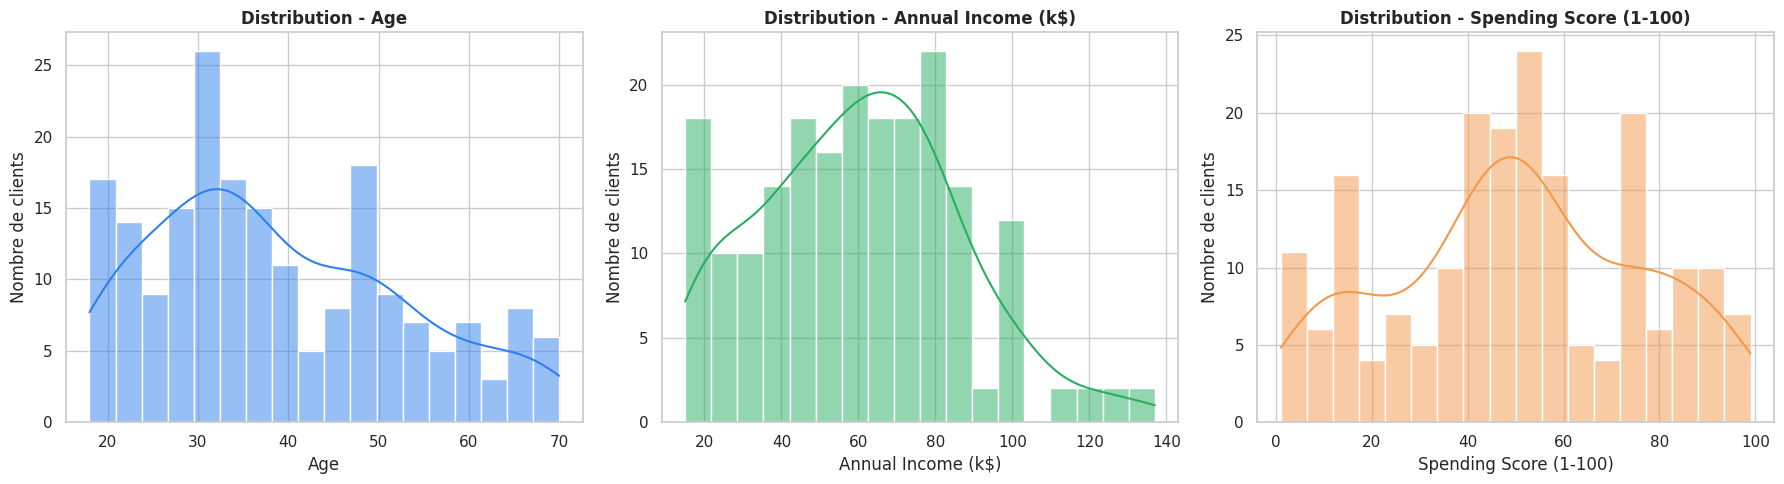

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

numeric_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
for ax, col, color in zip(axes, numeric_cols, PALETTE[:3]):
    sns.histplot(data=df, x=col, kde=True, ax=ax, color=color, bins=18)
    ax.set_title(f"Distribution - {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Nombre de clients")

plt.tight_layout()
plt.show()

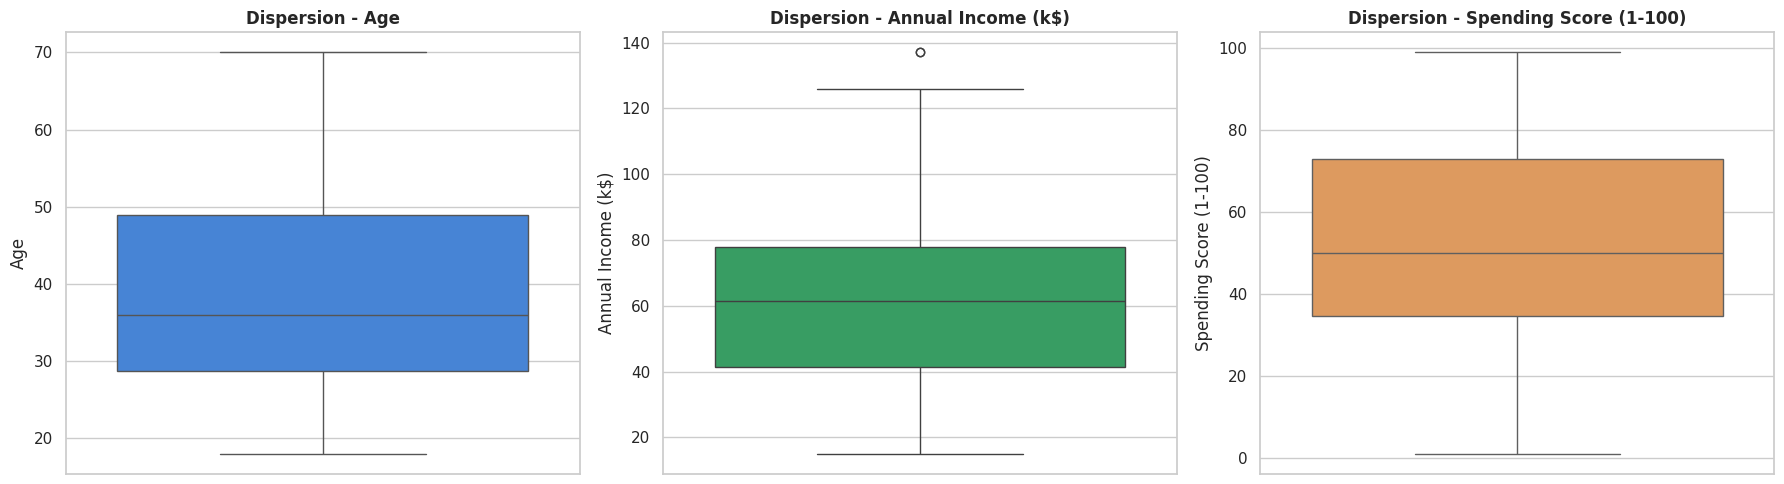

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, color in zip(axes, numeric_cols, PALETTE[:3]):
    sns.boxplot(data=df, y=col, ax=ax, color=color)
    ax.set_title(f"Dispersion - {col}")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

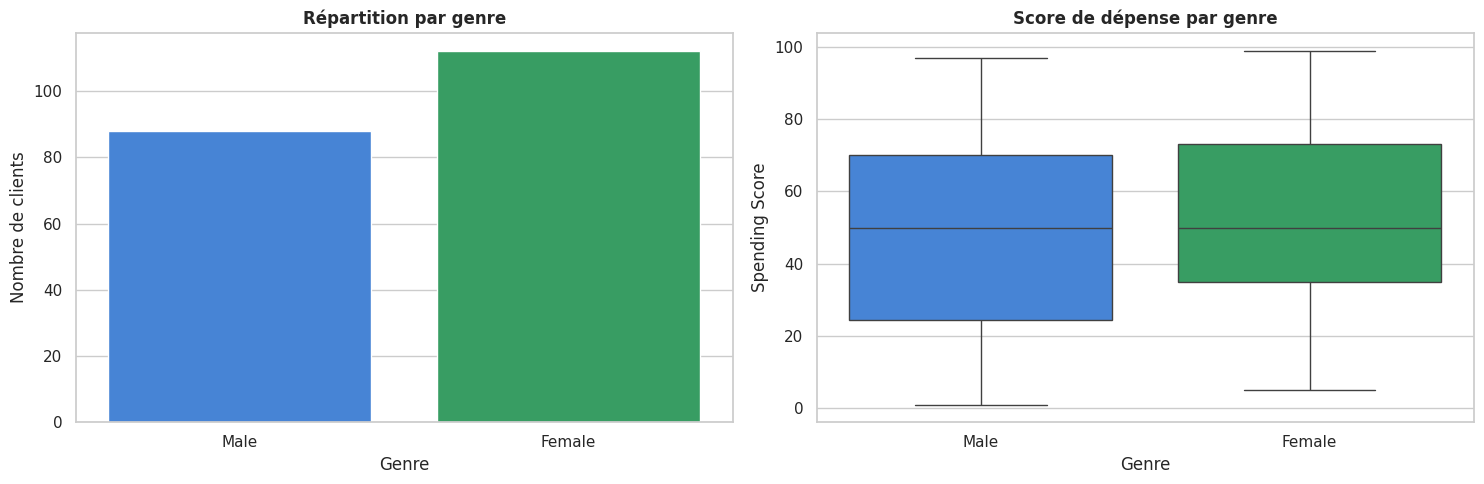

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=df, x="Gender", palette=PALETTE[:2], ax=axes[0])
axes[0].set_title("Répartition par genre")
axes[0].set_xlabel("Genre")
axes[0].set_ylabel("Nombre de clients")

sns.boxplot(data=df, x="Gender", y="Spending Score (1-100)", palette=PALETTE[:2], ax=axes[1])
axes[1].set_title("Score de dépense par genre")
axes[1].set_xlabel("Genre")
axes[1].set_ylabel("Spending Score")

plt.tight_layout()
plt.show()

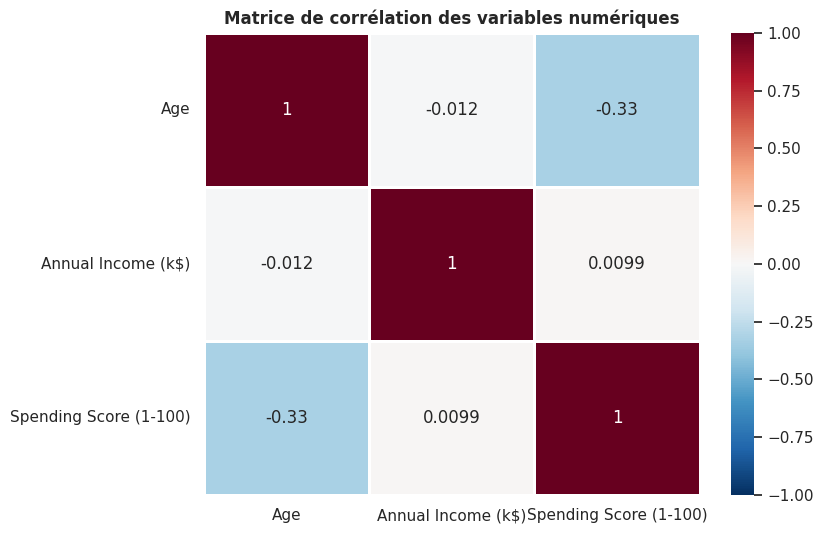

In [9]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1, linewidths=0.8)
plt.title("Matrice de corrélation des variables numériques")
plt.show()

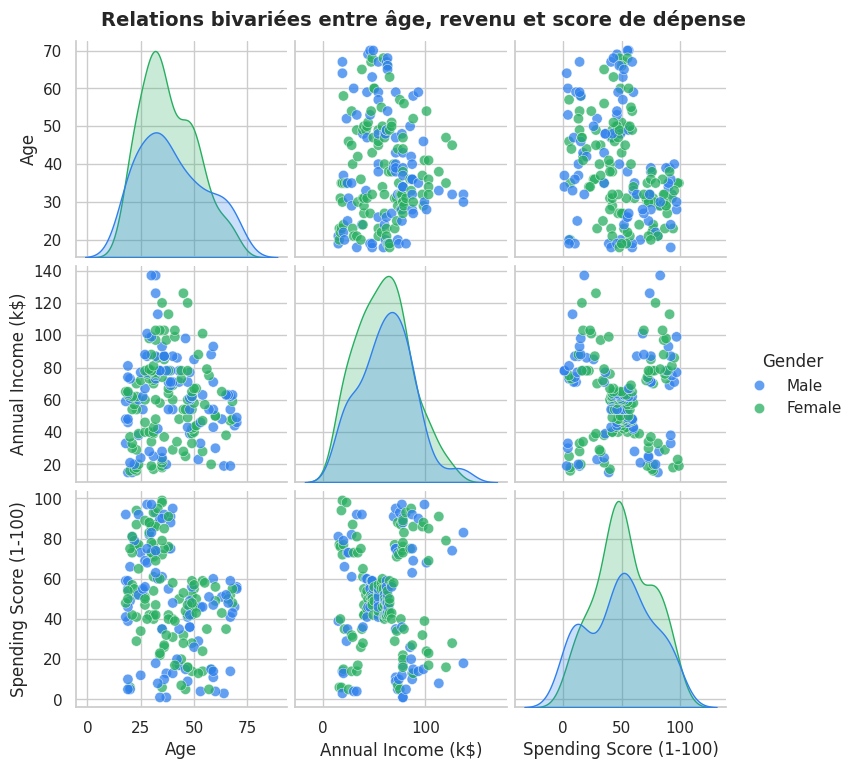

In [10]:
sns.pairplot(
    df,
    vars=numeric_cols,
    hue="Gender",
    palette=PALETTE[:2],
    diag_kind="kde",
    plot_kws={"alpha": 0.75, "s": 55, "edgecolor": "white", "linewidth": 0.4}
)
plt.suptitle("Relations bivariées entre âge, revenu et score de dépense", y=1.02, fontsize=14, fontweight="bold")
plt.show()

### Insights EDA ? retenir

- Le dataset est compact et propre : il se prête bien à une démonstration claire de clustering.
- `CustomerID` est un identifiant technique : il ne doit pas influencer les groupes.
- `Annual Income (k$)` et `Spending Score (1-100)` sont particulièrement intéressants pour créer des segments marketing actionnables.
- `Age` enrichit l'interprétation des personas et peut révéler des comportements générationnels.
- `Gender` est encodé pour l'analyse, mais doit être utilisé avec prudence dans une logique de ciblage responsable.

## 5. Préparation des Données

La préparation suit trois principes :

1. Exclure les identifiants non informatifs.
2. Encoder les variables catégorielles.
3. Standardiser les variables pour éviter qu'une échelle domine les distances.

In [11]:
# Encodage du genre pour disposer d'une version num?rique exploitable.
# Female/Male deviennent 0/1 selon l'ordre appris par LabelEncoder.
encoder = LabelEncoder()
df["Gender_Encoded"] = encoder.fit_transform(df["Gender"])

feature_cols = ["Gender_Encoded", "Age", "Annual Income (k$)", "Spending Score (1-100)"]
business_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

X = df[feature_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
display(X_scaled_df.head())

,Gender_Encoded,Age,Annual Income (k$),Spending Score (1-100)
0,1.128152,-1.424569,-1.738999,-0.434801
1,1.128152,-1.281035,-1.738999,1.195704
2,-0.886405,-1.352802,-1.700830,-1.715913
3,-0.886405,-1.137502,-1.700830,1.040418
4,-0.886405,-0.563369,-1.662660,-0.395980


In [12]:
quality_checks = pd.DataFrame({
    "variable": feature_cols,
    "mean_after_scaling": X_scaled_df.mean().round(4).values,
    "std_after_scaling": X_scaled_df.std(ddof=0).round(4).values
})

display(quality_checks)

,variable,mean_after_scaling,std_after_scaling
0,Gender_Encoded,0.0,1.0
1,Age,-0.0,1.0
2,Annual Income (k$),-0.0,1.0
3,Spending Score (1-100),-0.0,1.0


## 6. Modélisation - Clustering

Trois familles de modèles sont comparées :

- **K-Means** : efficace, lisible, très utilisé en segmentation marketing.
- **Clustering hiérarchique (CAH)** : utile pour comprendre la structure progressive des groupes via un dendrogramme.
- **DBSCAN** : détecte des formes non sphériques et des points atypiques, mais peut être moins adapté si les densités sont hétérogènes.

### 6.1 K-Means : Elbow Method et Silhouette

In [13]:
k_range = range(2, 11)
kmeans_results = []

for k in k_range:
    model = KMeans(n_clusters=k, init="k-means++", n_init=50, random_state=RANDOM_STATE)
    labels = model.fit_predict(X_scaled)
    kmeans_results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, labels),
        "davies_bouldin": davies_bouldin_score(X_scaled, labels)
    })

kmeans_eval = pd.DataFrame(kmeans_results)
display(kmeans_eval.style.format({
    "inertia": "{:.2f}",
    "silhouette": "{:.3f}",
    "calinski_harabasz": "{:.1f}",
    "davies_bouldin": "{:.3f}"
}))

,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,2,588.80,0.252,71.0,1.614
1,3,476.79,0.260,66.8,1.357
2,4,386.71,0.302,69.8,1.291
3,5,325.09,0.318,71.2,1.149
4,6,275.05,0.335,74.1,1.018
5,7,235.60,0.357,77.1,0.974
6,8,199.72,0.387,82.4,0.947
7,9,174.12,0.403,85.8,0.876
8,10,152.03,0.421,90.0,0.833


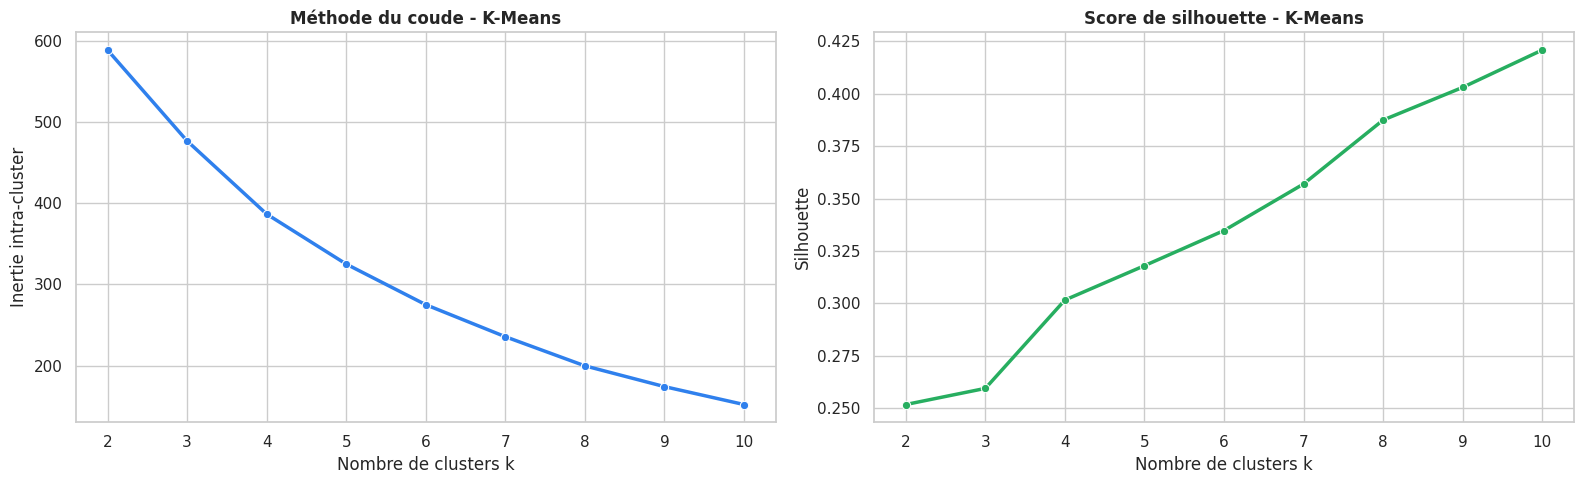

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.lineplot(data=kmeans_eval, x="k", y="inertia", marker="o", linewidth=2.5, color=PALETTE[0], ax=axes[0])
axes[0].set_title("Méthode du coude - K-Means")
axes[0].set_xlabel("Nombre de clusters k")
axes[0].set_ylabel("Inertie intra-cluster")
axes[0].set_xticks(list(k_range))

sns.lineplot(data=kmeans_eval, x="k", y="silhouette", marker="o", linewidth=2.5, color=PALETTE[1], ax=axes[1])
axes[1].set_title("Score de silhouette - K-Means")
axes[1].set_xlabel("Nombre de clusters k")
axes[1].set_ylabel("Silhouette")
axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.show()

In [15]:
best_k_silhouette = int(kmeans_eval.loc[kmeans_eval["silhouette"].idxmax(), "k"])

# En segmentation marketing, k=5 est souvent tr?s lisible sur ce dataset.
# Le notebook choisit automatiquement le meilleur k silhouette, tout en permettant un override simple.
FINAL_K = best_k_silhouette

kmeans_final = KMeans(n_clusters=FINAL_K, init="k-means++", n_init=50, random_state=RANDOM_STATE)
df["Cluster_KMeans"] = kmeans_final.fit_predict(X_scaled)

print(f"Nombre de clusters retenu automatiquement pour K-Means : {FINAL_K}")

Nombre de clusters retenu automatiquement pour K-Means : 10


### 6.2 Clustering Hiérarchique (CAH) avec Dendrogramme

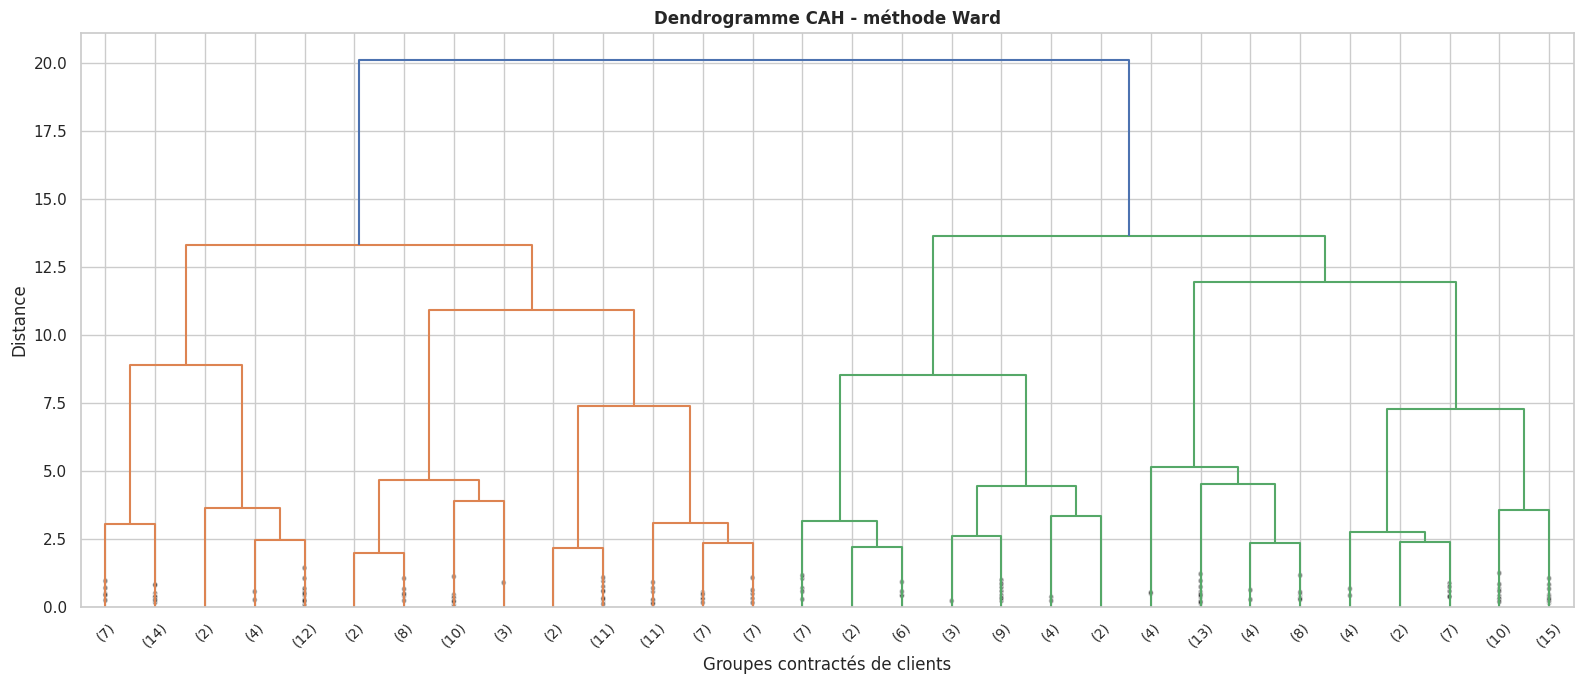

In [16]:
linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(16, 7))
dendrogram(
    linked,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=45,
    leaf_font_size=10,
    show_contracted=True,
    color_threshold=None
)
plt.title("Dendrogramme CAH - méthode Ward")
plt.xlabel("Groupes contractés de clients")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [17]:
hierarchical_results = []
for k in k_range:
    model = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = model.fit_predict(X_scaled)
    hierarchical_results.append({
        "k": k,
        "silhouette": silhouette_score(X_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, labels),
        "davies_bouldin": davies_bouldin_score(X_scaled, labels)
    })

hierarchical_eval = pd.DataFrame(hierarchical_results)
display(hierarchical_eval.style.format({
    "silhouette": "{:.3f}",
    "calinski_harabasz": "{:.1f}",
    "davies_bouldin": "{:.3f}"
}))

best_k_h = int(hierarchical_eval.loc[hierarchical_eval["silhouette"].idxmax(), "k"])
hierarchical_final = AgglomerativeClustering(n_clusters=best_k_h, linkage="ward")
df["Cluster_CAH"] = hierarchical_final.fit_predict(X_scaled)
print(f"Meilleur k CAH selon silhouette : {best_k_h}")

,k,silhouette,calinski_harabasz,davies_bouldin
0,2,0.242,67.0,1.661
1,3,0.248,57.7,1.451
2,4,0.263,60.3,1.402
3,5,0.287,64.5,1.220
4,6,0.310,70.2,1.073
5,7,0.346,72.7,1.011
6,8,0.379,77.5,0.968
7,9,0.392,81.1,0.879
8,10,0.418,87.6,0.825


Meilleur k CAH selon silhouette : 10


### 6.3 DBSCAN : Recherche de densité et détection d'atypiques

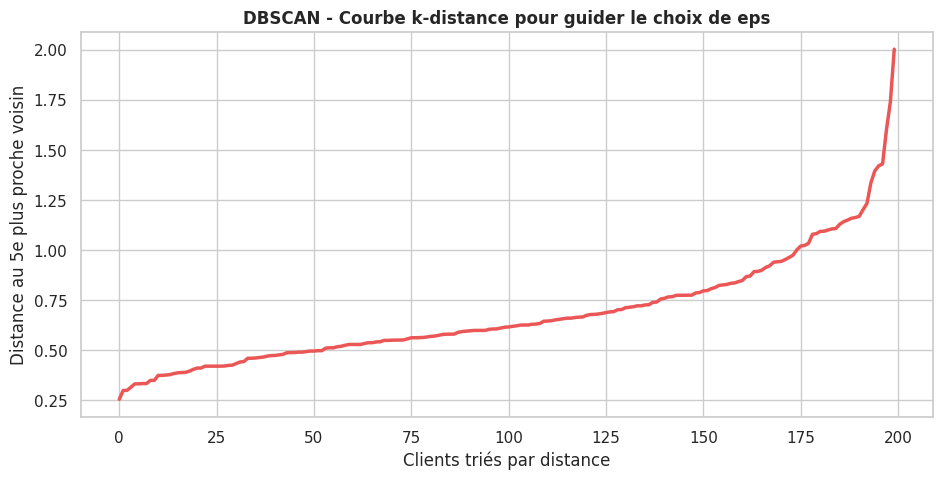

In [18]:
# Le graphique k-distance aide ? choisir eps : on cherche une rupture dans la courbe.
min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
k_distances = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(11, 5))
plt.plot(k_distances, color=PALETTE[3], linewidth=2.5)
plt.title("DBSCAN - Courbe k-distance pour guider le choix de eps")
plt.xlabel("Clients triés par distance")
plt.ylabel(f"Distance au {min_samples}e plus proche voisin")
plt.show()

In [19]:
dbscan_grid = []
for eps in np.arange(0.4, 1.8, 0.1):
    model = DBSCAN(eps=float(eps), min_samples=min_samples)
    labels = model.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_rate = np.mean(labels == -1)
    if n_clusters >= 2:
        mask = labels != -1
        sil = silhouette_score(X_scaled[mask], labels[mask]) if len(set(labels[mask])) > 1 else np.nan
    else:
        sil = np.nan
    dbscan_grid.append({
        "eps": round(float(eps), 2),
        "min_samples": min_samples,
        "n_clusters": n_clusters,
        "noise_rate": noise_rate,
        "silhouette_without_noise": sil
    })

dbscan_eval = pd.DataFrame(dbscan_grid)
display(dbscan_eval.style.format({"noise_rate": "{:.1%}", "silhouette_without_noise": "{:.3f}"}))

,eps,min_samples,n_clusters,noise_rate,silhouette_without_noise
0,0.400000,5,4,82.5%,0.712
1,0.500000,5,9,52.5%,0.540
2,0.600000,5,9,31.0%,0.341
3,0.700000,5,7,18.5%,0.277
4,0.800000,5,5,9.5%,0.227
5,0.900000,5,2,6.5%,0.292
6,1.000000,5,2,6.5%,0.292
7,1.100000,5,2,3.5%,0.285
8,1.200000,5,2,0.5%,0.279
9,1.300000,5,2,0.5%,0.279


In [20]:
# S?lection automatique : au moins 2 clusters, bruit raisonnable, meilleure silhouette hors bruit.
candidates = dbscan_eval[(dbscan_eval["n_clusters"] >= 2) & (dbscan_eval["noise_rate"] <= 0.35)].dropna()

if len(candidates) > 0:
    best_eps = float(candidates.sort_values("silhouette_without_noise", ascending=False).iloc[0]["eps"])
else:
    best_eps = 0.9

dbscan_final = DBSCAN(eps=best_eps, min_samples=min_samples)
df["Cluster_DBSCAN"] = dbscan_final.fit_predict(X_scaled)

print(f"eps retenu pour DBSCAN : {best_eps}")
print("Distribution des labels DBSCAN :")
display(df["Cluster_DBSCAN"].value_counts().sort_index().rename("nb_clients").to_frame())

eps retenu pour DBSCAN : 0.6
Distribution des labels DBSCAN :


,nb_clients
Cluster_DBSCAN,
-1,62
0,57
1,6
2,5
3,4
4,22
5,9
6,10
7,18


## 7. Evaluation et Choix du Modèle

Les métriques utilisées :

- **Silhouette** : plus le score est élevé, plus les clusters sont compacts et séparés.
- **Calinski-Harabasz** : plus le score est élevé, meilleure est la séparation relative.
- **Davies-Bouldin** : plus le score est faible, meilleure est la qualité.
- **Lisibilité métier** : critère indispensable pour une segmentation marketing.

In [21]:
def evaluate_labels(X_matrix, labels, model_name):
    labels = np.asarray(labels)
    mask = labels != -1
    n_clusters = len(set(labels[mask]))
    noise_rate = np.mean(labels == -1)

    if n_clusters < 2:
        return {
            "model": model_name,
            "n_clusters": n_clusters,
            "noise_rate": noise_rate,
            "silhouette": np.nan,
            "calinski_harabasz": np.nan,
            "davies_bouldin": np.nan
        }

    return {
        "model": model_name,
        "n_clusters": n_clusters,
        "noise_rate": noise_rate,
        "silhouette": silhouette_score(X_matrix[mask], labels[mask]),
        "calinski_harabasz": calinski_harabasz_score(X_matrix[mask], labels[mask]),
        "davies_bouldin": davies_bouldin_score(X_matrix[mask], labels[mask])
    }

model_comparison = pd.DataFrame([
    evaluate_labels(X_scaled, df["Cluster_KMeans"], f"K-Means k={FINAL_K}"),
    evaluate_labels(X_scaled, df["Cluster_CAH"], f"CAH k={best_k_h}"),
    evaluate_labels(X_scaled, df["Cluster_DBSCAN"], f"DBSCAN eps={best_eps}")
])

display(model_comparison.style.format({
    "noise_rate": "{:.1%}",
    "silhouette": "{:.3f}",
    "calinski_harabasz": "{:.1f}",
    "davies_bouldin": "{:.3f}"
}))

,model,n_clusters,noise_rate,silhouette,calinski_harabasz,davies_bouldin
0,K-Means k=10,10,0.0%,0.421,90.0,0.833
1,CAH k=10,10,0.0%,0.418,87.6,0.825
2,DBSCAN eps=0.6,9,31.0%,0.341,43.0,0.861


In [22]:
fig = px.bar(
    model_comparison,
    x="model",
    y="silhouette",
    color="model",
    text="silhouette",
    title="Comparaison des modèles par score de silhouette",
    labels={"model": "Modèle", "silhouette": "Silhouette"}
)
fig.update_traces(texttemplate="%{text:.3f}", textposition="outside")
fig.update_layout(showlegend=False, yaxis_range=[0, max(0.1, model_comparison["silhouette"].max() * 1.2)])
fig.show()

### Choix final

Pour une segmentation client destinée au marketing, **K-Means** est retenu comme modèle principal lorsque ses métriques sont compétitives, car il offre :

- une lecture simple des centroïdes,
- une stabilité satisfaisante,
- une traduction directe en personas,
- une communication facile auprès de décideurs non techniques.

La CAH sert de validation structurelle et DBSCAN apporte une lecture complémentaire sur les éventuels points atypiques.

## 8. Visualisation des Segments

In [23]:
final_cluster_col = "Cluster_KMeans"
df["Segment"] = df[final_cluster_col].astype(str)

fig = px.scatter(
    df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    color="Segment",
    hover_data=["CustomerID", "Gender", "Age"],
    title="Segmentation K-Means - Revenu annuel vs Score de dépense",
    labels={"Annual Income (k$)": "Revenu annuel (k$)", "Spending Score (1-100)": "Score de dépense"}
)
fig.update_traces(marker=dict(size=10, opacity=0.85, line=dict(width=0.6, color="white")))
fig.show()

In [24]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
components_2d = pca_2d.fit_transform(X_scaled)

df["PCA1"] = components_2d[:, 0]
df["PCA2"] = components_2d[:, 1]

explained_2d = pca_2d.explained_variance_ratio_.sum()

fig = px.scatter(
    df,
    x="PCA1",
    y="PCA2",
    color="Segment",
    hover_data=["Gender", "Age", "Annual Income (k$)", "Spending Score (1-100)"],
    title=f"Projection PCA 2D des segments - Variance expliquée : {explained_2d:.1%}",
    labels={"PCA1": "Composante principale 1", "PCA2": "Composante principale 2"}
)
fig.update_traces(marker=dict(size=10, opacity=0.85, line=dict(width=0.6, color="white")))
fig.show()

In [25]:
pca_3d = PCA(n_components=3, random_state=RANDOM_STATE)
components_3d = pca_3d.fit_transform(X_scaled)

df["PCA3D_1"] = components_3d[:, 0]
df["PCA3D_2"] = components_3d[:, 1]
df["PCA3D_3"] = components_3d[:, 2]

explained_3d = pca_3d.explained_variance_ratio_.sum()

fig = px.scatter_3d(
    df,
    x="PCA3D_1",
    y="PCA3D_2",
    z="PCA3D_3",
    color="Segment",
    hover_data=["Gender", "Age", "Annual Income (k$)", "Spending Score (1-100)"],
    title=f"Projection PCA 3D interactive des segments - Variance expliqu?e : {explained_3d:.1%}",
    labels={"PCA3D_1": "PCA 1", "PCA3D_2": "PCA 2", "PCA3D_3": "PCA 3"}
)
fig.update_traces(marker=dict(size=5, opacity=0.85))
fig.update_layout(scene=dict(xaxis_title="PCA 1", yaxis_title="PCA 2", zaxis_title="PCA 3"))
fig.show()

## 9. Interprétation Métier & Recommandations Stratégiques

Cette section transforme les clusters en segments marketing. L'objectif n'est pas de simplement afficher des labels, mais de fournir des recommandations utilisables.

In [26]:
def build_segment_name(row):
    income = row["revenu_moyen_k"]
    spending = row["score_depense_moyen"]
    age = row["age_moyen"]

    income_q33, income_q66 = df["Annual Income (k$)"].quantile([0.33, 0.66])
    spending_q33, spending_q66 = df["Spending Score (1-100)"].quantile([0.33, 0.66])
    age_q33, age_q66 = df["Age"].quantile([0.33, 0.66])

    if income >= income_q66 and spending >= spending_q66:
        return "VIP Premium à Fort Potentiel"
    if income >= income_q66 and spending <= spending_q33:
        return "Aisés à Réactiver"
    if income <= income_q33 and spending >= spending_q66:
        return "Jeunes Dépensiers Enthousiastes" if age <= age_q33 else "Dépensiers Opportunistes"
    if income <= income_q33 and spending <= spending_q33:
        return "Clients Prudents à Budget Serré"
    if age >= age_q66 and spending <= spending_q33:
        return "Seniors économes"
    if spending >= spending_q66:
        return "Acheteurs Engagés"
    return "Clients équilibrés"

segment_profile = (
    df.groupby(final_cluster_col)
      .agg(
          nb_clients=("CustomerID", "count"),
          age_moyen=("Age", "mean"),
          revenu_moyen_k=("Annual Income (k$)", "mean"),
          score_depense_moyen=("Spending Score (1-100)", "mean"),
          part_femmes=("Gender", lambda s: (s == "Female").mean())
      )
      .reset_index()
)

segment_profile["poids_segment"] = segment_profile["nb_clients"] / len(df)
segment_profile["nom_segment"] = segment_profile.apply(build_segment_name, axis=1)

# Gestion des doublons éventuels de noms : ajout du numéro de cluster pour conserver une clé unique.
if segment_profile["nom_segment"].duplicated().any():
    segment_profile["nom_segment"] = segment_profile.apply(
        lambda r: f"{r['nom_segment']} - Groupe {int(r[final_cluster_col])}", axis=1
    )

segment_name_map = dict(zip(segment_profile[final_cluster_col], segment_profile["nom_segment"]))
df["Nom_Segment"] = df[final_cluster_col].map(segment_name_map)

segment_profile_display = segment_profile[[
    final_cluster_col, "nom_segment", "nb_clients", "poids_segment", "age_moyen",
    "revenu_moyen_k", "score_depense_moyen", "part_femmes"
]].copy()

segment_profile_display.columns = [
    "cluster", "segment", "nb_clients", "poids", "age_moyen",
    "revenu_moyen_k", "score_depense_moyen", "part_femmes"
]

segment_profile_display = segment_profile_display.sort_values("score_depense_moyen", ascending=False).reset_index(drop=True)

display(segment_profile_display.style.format({
    "poids": "{:.1%}",
    "age_moyen": "{:.1f}",
    "revenu_moyen_k": "{:.1f}",
    "score_depense_moyen": "{:.1f}",
    "part_femmes": "{:.1%}"
}))

,cluster,segment,nb_clients,poids,age_moyen,revenu_moyen_k,score_depense_moyen,part_femmes
0,7,VIP Premium à Fort Potentiel - Groupe 7,18,9.0%,33.3,87.1,82.7,0.0%
1,3,VIP Premium à Fort Potentiel - Groupe 3,21,10.5%,32.2,86.0,81.7,100.0%
2,8,Jeunes Dépensiers Enthousiastes - Groupe 8,13,6.5%,25.5,25.7,80.5,100.0%
3,1,Jeunes Dépensiers Enthousiastes - Groupe 1,24,12.0%,25.2,41.2,60.9,0.0%
4,4,Clients équilibrés - Groupe 4,26,13.0%,54.2,54.2,49.0,100.0%
5,6,Clients équilibrés - Groupe 6,25,12.5%,28.0,57.4,47.1,100.0%
6,0,Seniors économes - Groupe 0,26,13.0%,58.8,48.7,39.8,0.0%
7,9,Aisés à Réactiver - Groupe 9,14,7.0%,43.8,93.3,20.6,100.0%
8,2,Clients Prudents à Budget Serré - Groupe 2,14,7.0%,41.2,26.1,20.1,92.9%
9,5,Aisés à Réactiver - Groupe 5,19,9.5%,38.5,85.9,14.2,0.0%


In [27]:
fig = px.scatter(
    segment_profile,
    x="revenu_moyen_k",
    y="score_depense_moyen",
    size="nb_clients",
    color="nom_segment",
    text="nom_segment",
    title="Carte stratégique des segments : potentiel de valeur vs intensité de dépense",
    labels={
        "revenu_moyen_k": "Revenu moyen (k$)",
        "score_depense_moyen": "Score de dépense moyen",
        "nb_clients": "Nombre de clients",
        "nom_segment": "Segment"
    }
)
fig.update_traces(textposition="top center", marker=dict(opacity=0.82, line=dict(width=0.8, color="white")))
fig.update_layout(showlegend=False)
fig.show()

In [28]:
profile_long = segment_profile.melt(
    id_vars=[final_cluster_col, "nom_segment"],
    value_vars=["age_moyen", "revenu_moyen_k", "score_depense_moyen", "part_femmes"],
    var_name="indicateur",
    value_name="valeur"
)

fig = px.bar(
    profile_long,
    x="nom_segment",
    y="valeur",
    color="indicateur",
    barmode="group",
    title="Profil comparatif des segments",
    labels={"nom_segment": "Segment", "valeur": "Valeur", "indicateur": "Indicateur"}
)
fig.update_layout(xaxis_tickangle=-25)
fig.show()

In [29]:
# Radar chart : les indicateurs sont normalisés entre 0 et 1 pour comparer les formes de profils.
radar_cols = ["age_moyen", "revenu_moyen_k", "score_depense_moyen", "part_femmes"]
radar_df = segment_profile[["nom_segment"] + radar_cols].copy()

for col in radar_cols:
    min_val = radar_df[col].min()
    max_val = radar_df[col].max()
    radar_df[col] = (radar_df[col] - min_val) / (max_val - min_val) if max_val != min_val else 0.5

fig = go.Figure()
for _, row in radar_df.iterrows():
    values = [row[col] for col in radar_cols]
    fig.add_trace(go.Scatterpolar(
        r=values + [values[0]],
        theta=radar_cols + [radar_cols[0]],
        fill="toself",
        name=row["nom_segment"]
    ))

fig.update_layout(
    title="Radar chart des profils de segments normalisés",
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    showlegend=True
)
fig.show()

In [30]:
def recommendation(row):
    name = row["segment"]

    if "VIP" in name:
        return "Priorité haute : programme VIP, accès anticipé, offres premium personnalisées, invitation à des évènements exclusifs. Objectif : maximiser la valeur vie client et la fidélité."
    if "Réactiver" in name:
        return "Priorité haute : campagnes d'activation ciblées, bundles premium, avantages limités dans le temps, diagnostic des freins à l'achat. Objectif : convertir le pouvoir d'achat en dépenses."
    if "Dépensiers" in name or "Engagés" in name:
        return "Priorité croissance : offres expérientielles, nouveautés fréquentes, programme de parrainage, gamification. Objectif : entretenir l'engagement sans éroder la marge."
    if "Budget" in name or "?conomes" in name:
        return "Priorité efficacité : promotions sélectives, coupons intelligents, offres d'entrée de gamme, communication prix-valeur. Objectif : augmenter la fréquence sans sur-solliciter."
    return "Priorité nurturing : campagnes relationnelles, recommandations personnalisées, tests A/B sur incentives. Objectif : faire progresser le segment vers une dépense plus régulière."

segment_recommendations = segment_profile_display.copy()
segment_recommendations["recommandation_marketing"] = segment_recommendations.apply(recommendation, axis=1)

display(segment_recommendations[[
    "segment", "nb_clients", "poids", "age_moyen", "revenu_moyen_k", "score_depense_moyen", "recommandation_marketing"
]].style.format({
    "poids": "{:.1%}",
    "age_moyen": "{:.1f}",
    "revenu_moyen_k": "{:.1f}",
    "score_depense_moyen": "{:.1f}"
}))

,segment,nb_clients,poids,age_moyen,revenu_moyen_k,score_depense_moyen,recommandation_marketing
0,VIP Premium à Fort Potentiel - Groupe 7,18,9.0%,33.3,87.1,82.7,"Priorité haute : programme VIP, accès anticipé, offres premium personnalisées, invitation à des évènements exclusifs. Objectif : maximiser la valeur vie client et la fidélité."
1,VIP Premium à Fort Potentiel - Groupe 3,21,10.5%,32.2,86.0,81.7,"Priorité haute : programme VIP, accès anticipé, offres premium personnalisées, invitation à des évènements exclusifs. Objectif : maximiser la valeur vie client et la fidélité."
2,Jeunes Dépensiers Enthousiastes - Groupe 8,13,6.5%,25.5,25.7,80.5,"Priorité croissance : offres expérientielles, nouveautés fréquentes, programme de parrainage, gamification. Objectif : entretenir l'engagement sans éroder la marge."
3,Jeunes Dépensiers Enthousiastes - Groupe 1,24,12.0%,25.2,41.2,60.9,"Priorité croissance : offres expérientielles, nouveautés fréquentes, programme de parrainage, gamification. Objectif : entretenir l'engagement sans éroder la marge."
4,Clients équilibrés - Groupe 4,26,13.0%,54.2,54.2,49.0,"Priorité nurturing : campagnes relationnelles, recommandations personnalisées, tests A/B sur incentives. Objectif : faire progresser le segment vers une dépense plus régulière."
5,Clients équilibrés - Groupe 6,25,12.5%,28.0,57.4,47.1,"Priorité nurturing : campagnes relationnelles, recommandations personnalisées, tests A/B sur incentives. Objectif : faire progresser le segment vers une dépense plus régulière."
6,Seniors économes - Groupe 0,26,13.0%,58.8,48.7,39.8,"Priorité nurturing : campagnes relationnelles, recommandations personnalisées, tests A/B sur incentives. Objectif : faire progresser le segment vers une dépense plus régulière."
7,Aisés à Réactiver - Groupe 9,14,7.0%,43.8,93.3,20.6,"Priorité haute : campagnes d'activation ciblées, bundles premium, avantages limités dans le temps, diagnostic des freins à l'achat. Objectif : convertir le pouvoir d'achat en dépenses."
8,Clients Prudents à Budget Serré - Groupe 2,14,7.0%,41.2,26.1,20.1,"Priorité efficacité : promotions sélectives, coupons intelligents, offres d'entrée de gamme, communication prix-valeur. Objectif : augmenter la fréquence sans sur-solliciter."
9,Aisés à Réactiver - Groupe 5,19,9.5%,38.5,85.9,14.2,"Priorité haute : campagnes d'activation ciblées, bundles premium, avantages limités dans le temps, diagnostic des freins à l'achat. Objectif : convertir le pouvoir d'achat en dépenses."


### Lecture stratégique des segments

Les segments à **revenu élevé et score de dépense élevé** sont les plus prioritaires pour les campagnes premium et la fidélisation avancée.  
Les segments à **revenu élevé mais score de dépense faible** représentent un gisement de croissance : ils ont la capacité d'achat, mais ne sont pas encore suffisamment activés.  
Les segments à **revenu faible mais score de dépense élevé** doivent être adressés avec des offres attractives mais maîtrisées pour préserver la marge.  
Les segments à **faible score de dépense** nécessitent des campagnes plus sélectives, orientées valeur perçue, fréquence et réactivation.

## 10. Conclusion & Perspectives

### Conclusion

Ce projet montre comment passer d'un dataset client simple à une segmentation marketing complète : exploration, préparation, comparaison de modèles, visualisation interactive et recommandations actionnables.

Le modèle final est sélectionné non seulement sur des métriques de clustering, mais aussi sur sa capacité à produire des groupes lisibles par les équipes métier.

### Perspectives d'amélioration

- Ajouter des variables transactionnelles pour construire une segmentation **RFM** : récence, fréquence, montant.
- Tester des modèles probabilistes comme **Gaussian Mixture Models (GMM)** pour obtenir des probabilités d'appartenance aux segments.
- Mesurer la stabilité des clusters par bootstrap ou sur plusieurs périodes.
- Connecter les segments à des KPIs business : conversion, panier moyen, marge, churn, lifetime value.
- Déployer un pipeline de scoring pour affecter automatiquement les nouveaux clients ? un segment.
- Réaliser des tests A/B par segment afin de valider l'impact réel des recommandations marketing.

> Ceci est une **projection** de ma part dans un environnement de travail réel, toute critique ou suggestion est la bienvenue! ...